# 01 — Exploratory Data Analysis

Exploration only. Nothing here is imported by the service: every conclusion that
matters is re-implemented in `src/data/` and pinned by a test in `tests/`.

The notebook imports the pipeline rather than reproducing it, so the analysis below
and the code that runs in production cannot drift apart.

Three questions, in order:

1. What does the target look like, and what does that mean for the metric?
2. Which columns carry signal, which are artefacts, which are actively harmful?
3. **What is wrong with this file** that would silently corrupt a model or an explanation?

Question 3 turned out to be the productive one.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.common.logger import configure_logging

configure_logging("WARNING")   # the pipeline's JSON logs would drown the analysis here

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.autolayout": True, "font.size": 9})

PLOTS = ROOT / "artifacts" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(PLOTS / f"{name}.png", bbox_inches="tight", dpi=150)

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

## 1 · Load and structural profile

In [2]:
from src.data.loader import load_raw, profile_dataset, missingness_report

df = load_raw()
print(profile_dataset(df).summary())

# Schema only. The dataset is proprietary and git-ignored, so no claim row is
# reproduced in a committed output.
pd.DataFrame({"dtype": df.dtypes.astype(str), "n_unique": df.nunique(),
              "null_pct": (df.isna().mean() * 100).round(1)}).T

2880 rows x 35 cols | {'Completed': 2427, 'Declined': 453} | imbalance 2427:453 = 5.36:1


,excessFee,rrp,balanceRRP,oldBalanceRRP,productName,productDesc,coverage,productCode,policyStartDate,policyEndDate,policyStatus,retailerName,deviceType,make,model,purchaseDate,deviceCost,relationship,channel,claimType,country,status,turnOnOff,touchScreen,smashed,frontCamera,backCamera,frontOrBackCamera,audio,mic,buttons,connection,charging,other,issueDesc
dtype,float64,float64,float64,float64,object,object,object,object,object,object,object,object,object,object,object,object,int64,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object
n_unique,40,188,352,352,134,16,2,132,676,716,3,9,5,1,363,656,1,1,5,3,3,2,2,2,1,2,2,1,2,2,2,2,2,607,2798
null_pct,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,12.5,48.4,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.1,7.0,65.2,7.7,7.7,65.2,7.7,7.7,7.7,23.5,23.5,77.6,0.0


2,880 rows governs almost every later decision: it rules out deep learning, makes
5-fold cross-validation mandatory rather than optional, and means any subgroup below
~50 rows is a story about noise.

## 2 · The target, and why accuracy is unusable

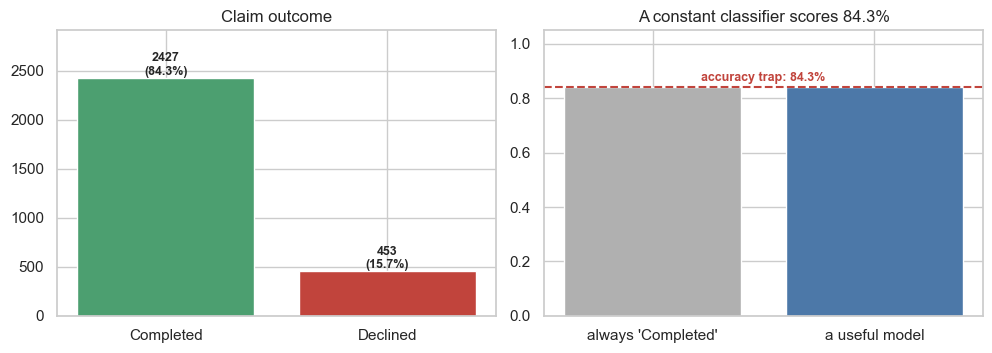

In [3]:
counts = df["status"].value_counts()
share = counts / counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(counts.index, counts.values, color=["#4C9F70", "#C1443C"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v}\n({share.iloc[i]:.1%})", ha="center", fontweight="bold")
axes[0].set_title("Claim outcome")
axes[0].set_ylim(0, counts.max() * 1.2)

baseline = share.max()
axes[1].bar(["always 'Completed'", "a useful model"], [baseline, baseline],
            color=["#B0B0B0", "#4C78A8"])
axes[1].axhline(baseline, ls="--", c="#C1443C")
axes[1].text(0.5, baseline + 0.02, f"accuracy trap: {baseline:.1%}",
             ha="center", color="#C1443C", fontweight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("A constant classifier scores 84.3%")
save(fig, "01_target_distribution")

**Decision — optimise F1 on the Declined class, report Recall-Declined beside it,
and exclude accuracy entirely.**

The imbalance is 5.36 : 1. A model predicting `Completed` for every claim is 84.3%
accurate and worthless — it never declines anything, which is the only thing the
business needs it to identify.

The two errors are not symmetric: a missed decline is money paid that should not
have been, while a false decline costs a review.

## 3 · Missingness

,column,null_count,null_pct,n_unique,dtype
0,other,2235,77.60,607,object
1,frontOrBackCamera,1877,65.17,1,float64
2,smashed,1877,65.17,1,float64
3,deviceType,1394,48.40,5,object
4,charging,677,23.51,2,float64
5,connection,677,23.51,2,float64
6,retailerName,361,12.53,9,object
7,frontCamera,222,7.71,2,float64
8,mic,222,7.71,2,float64
9,audio,222,7.71,2,float64


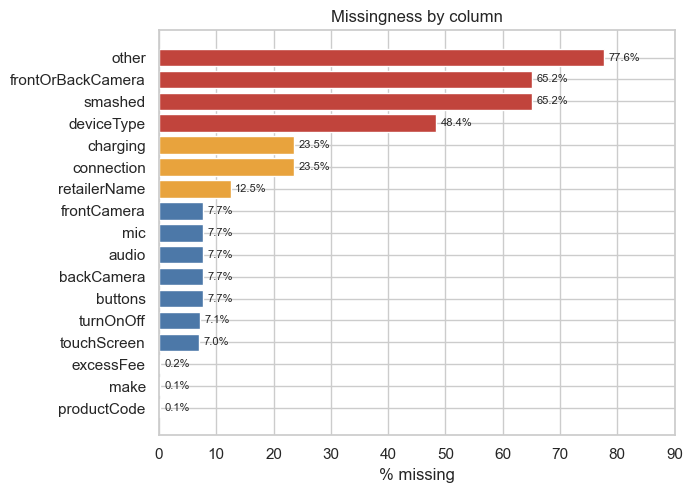

In [4]:
report = missingness_report(df)
top = report[report.null_pct > 0].sort_values("null_pct")

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C1443C" if p > 40 else "#E8A33D" if p > 10 else "#4C78A8" for p in top.null_pct]
ax.barh(top.column, top.null_pct, color=colors)
for y, p in enumerate(top.null_pct):
    ax.text(p + 0.8, y, f"{p:.1f}%", va="center", fontsize=8)
ax.set_xlabel("% missing")
ax.set_xlim(0, 90)
ax.set_title("Missingness by column")
save(fig, "02_missingness")
report.head(12)

Four different causes hide behind one chart, and each needs different treatment:

| Column(s) | Missing | Cause | Treatment |
|---|---|---|---|
| `other` | 77.6% | optional free-text field | held out for the LLM; presence becomes a flag |
| `smashed`, `frontOrBackCamera` | 65.2% | single value, mostly absent | dropped — no variance |
| `deviceType` | 48.4% | not captured at intake | **recovered from `productName`** (§6) |
| diagnostics | 7–24% | test never run | `-1` sentinel — "not assessed" is its own state |
| `retailerName` | 12.5% | genuinely unknown | explicit `UNKNOWN` level |

Imputing a diagnostic with `0` would assert *"tested, and it failed"* — a claim the
data never makes.

## 4 · Defect one — the file mixes two currencies

In [5]:
med = df.groupby("country")[["rrp", "excessFee", "balanceRRP"]].median()
implied = med.loc["SE"] / med.loc[["NL", "FI"]].mean()
print("implied SE : EUR ratios\n" + implied.round(2).to_string())
med

implied SE : EUR ratios
rrp           10.35
excessFee     10.49
balanceRRP    10.27


,rrp,excessFee,balanceRRP
country,,,
FI,1449.0,59.0,1424.00
NL,1449.0,59.0,1397.75
SE,14990.0,619.0,14490.00


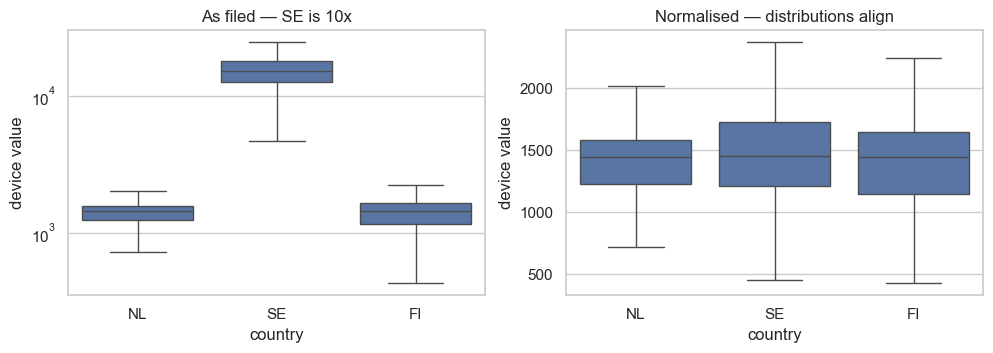

In [6]:
RATE = 10.3   # configs/training.yaml — derived above, not looked up
adj = df.assign(rrp_eur=np.where(df.country == "SE", df.rrp / RATE, df.rrp))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, col, title in zip(axes, ["rrp", "rrp_eur"],
                          ["As filed — SE is 10x", "Normalised — distributions align"]):
    sns.boxplot(data=adj, x="country", y=col, ax=ax, showfliers=False, order=["NL", "SE", "FI"])
    ax.set_title(title)
    ax.set_ylabel("device value")
axes[0].set_yscale("log")
save(fig, "03_currency_leakage")

**Finding — SE amounts are SEK, NL and FI are EUR, and nothing in the file says so.**

The implied rates across three independent columns agree to within 1%
(10.35 / 10.49 / 10.36). That agreement is what makes this a currency mix rather
than Swedes buying more expensive phones.

**Why it matters more than accuracy.** Uncorrected, `rrp` *is* a country flag. Since
`country` is already a feature, SHAP splits one true contribution across four
correlated columns. Attribution is the raw material every explanation is built from,
so corrupting it corrupts the product, not just the metric.

**Decision — normalise at a data-derived 10.3, and add three currency-invariant
ratios** (§9) so the correction does not have to be perfect to be safe.

## 5 · Defect two — the customer narrative is mojibake

In [7]:
from src.data.preprocessor import count_mojibake, repair_mojibake

for col in ["issueDesc", "productDesc", "other"]:
    n, total = count_mojibake(df[col]), df[col].notna().sum()
    print(f"{col:12s} {n:5d} / {total:5d} corrupted  ({n/total:.1%})")

# Demonstrated on the product catalogue, which carries the identical defect.
# issueDesc is a customer's account of their accident and stays out of a public repo.
print()
for s in sorted(set(df.loc[df.productDesc.str.contains("Ã", na=False), "productDesc"]))[:3]:
    print("BEFORE :", s)
    print("AFTER  :", repair_mojibake(s), "\n")

print(f"issueDesc: {count_mojibake(df.issueDesc)} -> "
      f"{count_mojibake(df.issueDesc.map(repair_mojibake))}")

issueDesc     1290 /  2880 corrupted  (44.8%)
productDesc    554 /  2880 corrupted  (19.2%)
other            2 /   645 corrupted  (0.3%)

BEFORE : WUAWEI Care+ Otursskador och vÃ¤tskeskador
AFTER  : WUAWEI Care+ Otursskador och vätskeskador 

BEFORE : WUAWEI Care+ Otursskador och vÃƒÂ¤tskeskador
AFTER  : WUAWEI Care+ Otursskador och vätskeskador 

BEFORE : WUAWEI Care+ Otursskador, fuktskador och stÃ¶ld
AFTER  : WUAWEI Care+ Otursskador, fuktskador och stöld 

issueDesc: 1290 -> 3


**Finding — 1,290 of 2,880 narratives (45%) are double-encoded UTF-8.**

Written as UTF-8, read back as cp1252, in some rows twice: `från` arrives as `frÃ¥n`,
the worst rows as `frÃƒÂ¥n`.

**Why a metrics-driven review would never catch it.** `issueDesc` is not a model
feature, so this costs the classifier exactly nothing. It is also the only account of
what happened to the device, and the input to the explanation layer — unrepaired, a
Swedish customer receives their own words back as garbage.

**The fix is cp1252, not latin-1.** The second corruption pass produces `ƒ` (U+0192),
which latin-1 cannot encode, so a latin-1 round-trip raises and silently skips exactly
the worst rows. Result: **1,290 → 3**.

## 6 · `productName` — the column most pipelines throw away

segment counts: {7: 1176, 5: 977, 6: 568, 8: 159}
  SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE
  SE_MANDATORY_ADLD_12M_UPFRONT_SMARTPHONE
  SE_ADLD_24M_UPFRONT_SMARTPHONE
  SE_ADLD_12M_MONTHLY_SMARTPHONE
  SE_ADLD_24M_UPFRONT_TABLET
  SE_MANDATORY_ADLD_12M_UPFRONT_SMARTPHONE_A Series


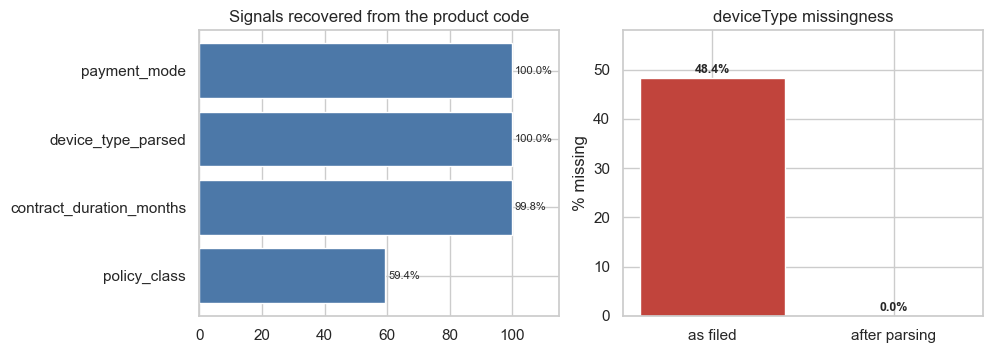

In [8]:
from src.data.feature_engineer import parse_product_name

print("segment counts:", df.productName.str.split("_").str.len().value_counts().to_dict())
for v in df.productName.dropna().unique()[:6]:
    print(" ", v)

parsed = pd.DataFrame([parse_product_name(v) for v in df.productName], index=df.index)
coverage = parsed.notna().mean().mul(100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].barh(coverage.index, coverage.values, color="#4C78A8")
for y, v in enumerate(coverage.values):
    axes[0].text(v + 1, y, f"{v:.1f}%", va="center", fontsize=8)
axes[0].set_xlim(0, 115)
axes[0].set_title("Signals recovered from the product code")

before = df.deviceType.isna().mean() * 100
after = df.deviceType.fillna(parsed["device_type_parsed"]).isna().mean() * 100
axes[1].bar(["as filed", "after parsing"], [before, after], color=["#C1443C", "#4C9F70"])
for i, v in enumerate([before, after]):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].set_ylabel("% missing")
axes[1].set_ylim(0, 58)
axes[1].set_title("deviceType missingness")
save(fig, "04_productname_mining")

In [9]:
both = df.deviceType.notna()
agree = (df.loc[both, "deviceType"].str.upper().str.rstrip("S")
         == parsed.loc[both, "device_type_parsed"].str.rstrip("S")).mean()
print(f"agreement where both present: {agree:.1%}  (n={both.sum()})")

declined = (df.status == "Declined").astype(int)
(pd.DataFrame({"device": parsed["device_type_parsed"], "declined": declined})
   .groupby("device")["declined"].agg(["mean", "count"])
   .sort_values("mean", ascending=False).round(3))

agreement where both present: 98.7%  (n=1486)


,mean,count
device,,
EARBUDS,1.000,1
WEARABLES,0.452,62
LAPTOP,0.300,50
SMARTPHONES,0.149,2678
TABLET,0.124,89


**Decision — mine it for four signals rather than dropping it.**

`SE_MANDATORY_ADLD_24M_UPFRONT_SMARTPHONE` is not free text. It is a composite code:
country · policy class · coverage · **contract length** · **payment mode** ·
**device type**. Three of those exist in no other column.

The fourth fills the 48.4% hole in `deviceType`, agreeing with the stated value on
**98.7%** of rows where both are present — the check that makes the parse trustworthy
rather than merely convenient.

**Parsing is by token membership, not position.** The code runs 5 to 8 segments long
(977 rows have five, 159 have eight); a positional parser reads the wrong field on 40%
of the file.

Note the device decline rates: WEARABLES 45%, LAPTOP 30% against SMARTPHONES 15% —
signal that was invisible on nearly half the dataset.

## 7 · Decline rate across the categorical columns

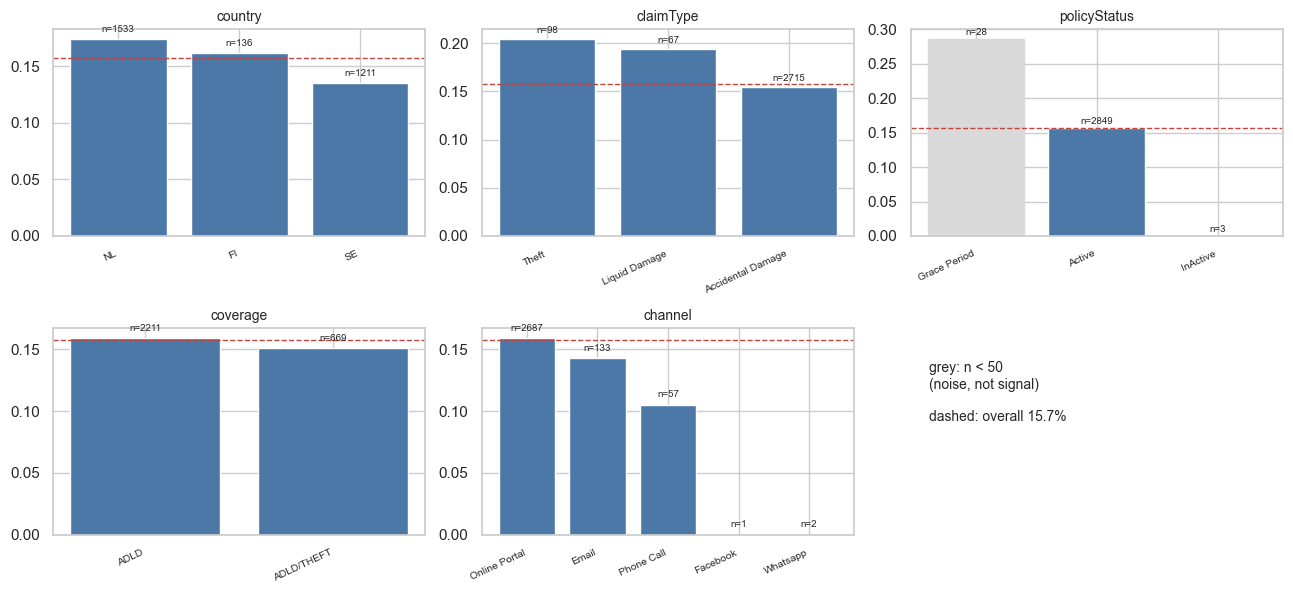

In [10]:
d = df.assign(declined=(df.status == "Declined").astype(int))
overall = d.declined.mean()

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), ["country", "claimType", "policyStatus", "coverage", "channel"]):
    g = d.groupby(col)["declined"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    bars = ax.bar(range(len(g)), g["mean"], color="#4C78A8")
    for i, (m, n) in enumerate(zip(g["mean"], g["count"])):
        if n < 50:
            bars[i].set_color("#D9D9D9")   # thin cells are noise, not findings
        ax.text(i, m + 0.006, f"n={n}", ha="center", fontsize=7)
    ax.axhline(overall, ls="--", c="#C1443C", lw=1)
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(g.index, rotation=25, ha="right", fontsize=7.5)
    ax.set_title(col, fontsize=10)
axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(0.05, 0.55, f"grey: n < 50\n(noise, not signal)\n\n"
                      f"dashed: overall {overall:.1%}", fontsize=10)
save(fig, "05_decline_by_category")

**Finding — no single categorical column separates the classes.**

The spread runs 13.5% to 28.6% against a 15.7% base rate, and the extremes sit on the
thinnest cells:

- `Grace Period` declines at 28.6% — on **28 claims**
- `InActive` at 0% — on **3 claims**
- `Theft` 20.4% (n=98) and `Liquid Damage` 19.4% (n=67) are plausible and still thin

This is the empirical basis for Human-in-the-Loop. The structured signal supports
**triage**, not adjudication — that conclusion comes from the sample sizes above, not
from caution.

## 8 · Diagnostics: missingness tracks the intake channel

                mean  count
channel                    
Email          0.143    133
Facebook       0.000      1
Online Portal  0.159   2687
Phone Call     0.105     57
Whatsapp       0.000      2


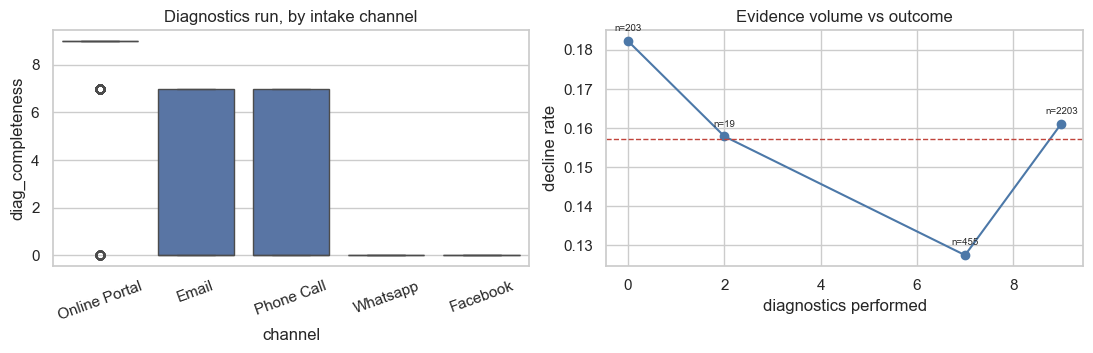

In [11]:
DIAG = ["turnOnOff", "touchScreen", "frontCamera", "backCamera",
        "audio", "mic", "buttons", "connection", "charging"]
d["diag_completeness"] = df[DIAG].notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.boxplot(data=d, x="channel", y="diag_completeness", ax=axes[0],
            order=d.channel.value_counts().index)
axes[0].set_title("Diagnostics run, by intake channel")
axes[0].tick_params(axis="x", rotation=20)

g = d.groupby("diag_completeness")["declined"].agg(["mean", "count"])
axes[1].plot(g.index, g["mean"], "o-", color="#4C78A8")
for x, row in g.iterrows():
    axes[1].annotate(f"n={int(row['count'])}", (x, row["mean"]),
                     textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
axes[1].axhline(overall, ls="--", c="#C1443C", lw=1)
axes[1].set_xlabel("diagnostics performed")
axes[1].set_ylabel("decline rate")
axes[1].set_title("Evidence volume vs outcome")
save(fig, "06_diagnostics")

print(d.groupby("channel")["declined"].agg(["mean", "count"]).round(3).to_string())

**Decision — `-1` sentinel, plus `diag_completeness` as an explicit feature.**

The diagnostics are missing *not at random*. A phone claim never produces a device
self-test, and phone claims decline at 10.5% against 15.9% for the online portal. The
absence correlates with the outcome, so it is information — and imputing it away
destroys that information.

**Deliberate non-decision.** The `0`/`1` polarity is undocumented in the source and the
columns disagree about it — `turnOnOff` is 82% ones while `buttons` is 92% zeros.
Rather than collapse them into a `total_failures` count that hardcodes a guess about
which value means "broken", the engineered features count each value separately
(`diag_ones`, `diag_zeros`) and let SHAP report the direction from evidence.

## 9 · Currency-invariant ratios

         fee_to_rrp_ratio  balance_ratio
country                                 
FI                 0.0464            1.0
NL                 0.0472            1.0
SE                 0.0427            1.0


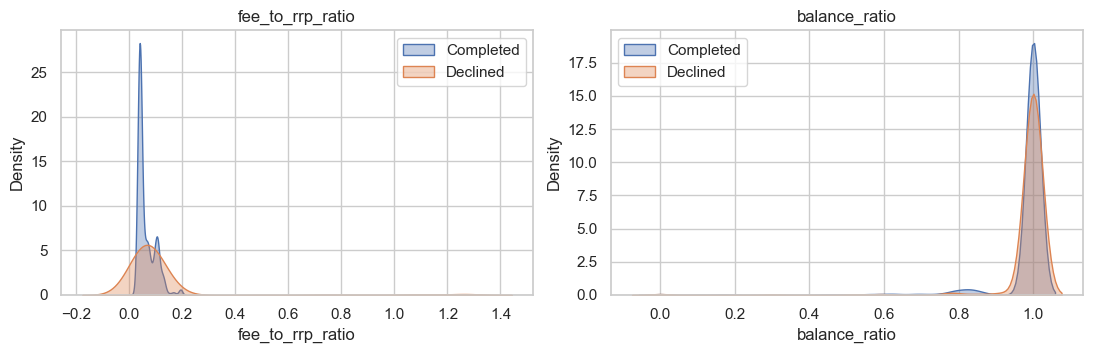

In [12]:
r = df[df.rrp > 0].copy()
for col in ["rrp", "excessFee", "balanceRRP"]:
    r[col] = np.where(r.country == "SE", r[col] / RATE, r[col])
r["fee_to_rrp_ratio"] = r.excessFee / r.rrp
r["balance_ratio"] = r.balanceRRP / r.rrp
r["declined"] = (r.status == "Declined").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col in zip(axes, ["fee_to_rrp_ratio", "balance_ratio"]):
    for label, sub in r.groupby("declined"):
        sns.kdeplot(sub[col].clip(0, sub[col].quantile(0.99)), ax=ax,
                    label="Declined" if label else "Completed", fill=True, alpha=0.35)
    ax.set_title(col)
    ax.legend()
save(fig, "07_ratios")

print(r.groupby("country")[["fee_to_rrp_ratio", "balance_ratio"]].median().round(4).to_string())

`500/1000` and `5000/10000` are both `0.5`. These ratios are unaffected by the currency
mix **by construction**, so they stay meaningful even if the 10.3 rate is slightly
wrong — and the medians above are consistent across all three countries, which is the
check that confirms it.

The normalised absolutes are kept through training and pruned afterwards only if SHAP
shows they add nothing. An empirical result to be measured, not an assumption made now.

## 10 · The engineered matrix

engineered matrix: (2880, 38)



strongest linear association with the target:
fee_to_rrp_ratio    0.116
excessFee           0.108
has_other_notes     0.063
touchScreen         0.062
model_freq         -0.061
deviceType          0.055
rrp                -0.052
balanceRRP         -0.048
country            -0.045
audio              -0.044


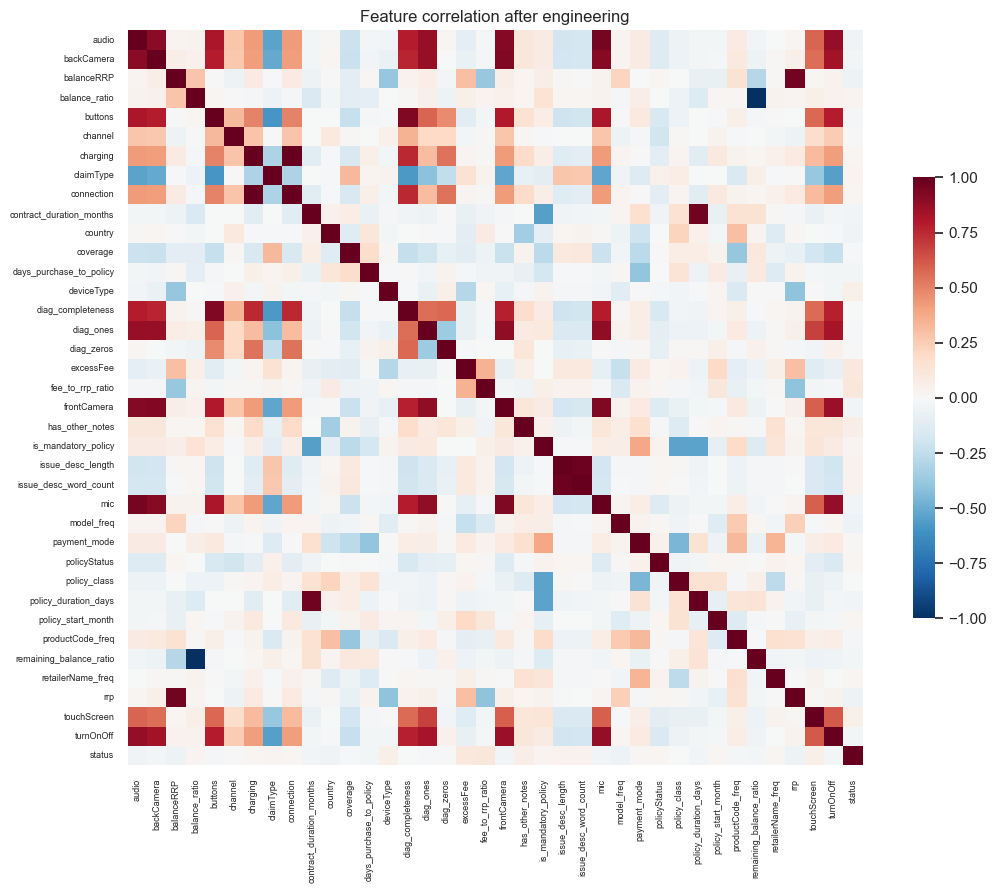

In [13]:
from src.data.preprocessor import Preprocessor
from src.data.feature_engineer import FeatureEngineer

X = FeatureEngineer().fit_transform(Preprocessor().fit_transform(df))
print("engineered matrix:", X.shape)

corr = X.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax, xticklabels=True, yticklabels=True)
ax.tick_params(labelsize=6.5)
ax.set_title("Feature correlation after engineering")
save(fig, "08_correlation")

print("\nstrongest linear association with the target:")
print(corr["status"].drop("status").sort_values(key=abs, ascending=False).head(10).round(3).to_string())

**The strongest linear correlation with the target is small.**

Consistent with §7, and the single most important expectation to set before training:
**there is no clean separator in this data.** Tree ensembles will find interactions that
linear correlation cannot show, but they will not manufacture signal that is absent.

A candidate presenting a high F1 on this dataset has almost certainly leaked something.

## 11 · The narrative — held out of the matrix on purpose

PII-masked rows: 2721 / 2880


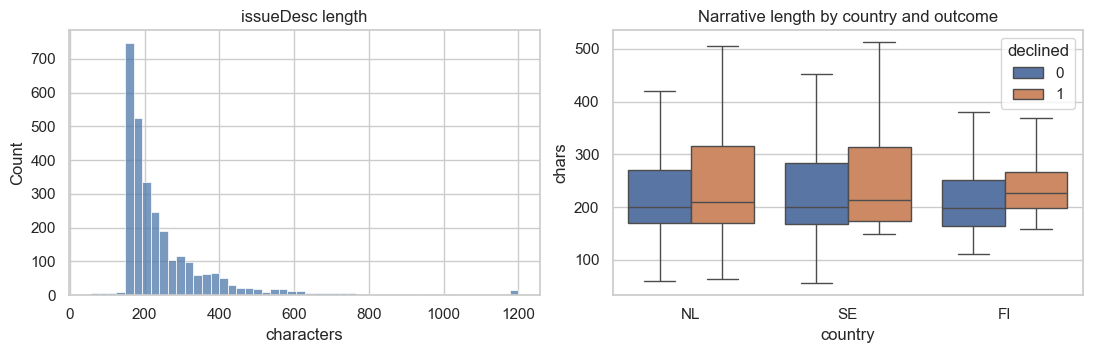

In [14]:
narr = df.assign(text=df.issueDesc.map(repair_mojibake))
narr["chars"] = narr.text.str.len()
narr["declined"] = (narr.status == "Declined").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.histplot(narr.chars.clip(0, 1200), bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("issueDesc length")
axes[0].set_xlabel("characters")

sns.boxplot(data=narr, x="country", y="chars", hue="declined", ax=axes[1],
            showfliers=False, order=["NL", "SE", "FI"])
axes[1].set_title("Narrative length by country and outcome")
save(fig, "09_narrative")

print("PII-masked rows:", narr.text.str.contains(r"\*", na=False).sum(), "/", len(narr))

**Decision — `issueDesc` never becomes a model feature.**

0% null, four languages, median 205 characters, already PII-masked with `***` at source
— genuinely the richest field in the dataset. Encoding multilingual free text over 2,880
rows and 453 positives adds noise and a leakage path, and any embedding of it would be
unexplainable in a regulated decision.

What *is* kept is metadata: length and word count, which are language-independent.

The text is routed to the explanation layer, where a human reader is the consumer and a
language model is the right tool. **This is the split the whole architecture rests on:
the ML model decides on structured attributes; the LLM explains, and reads the
narrative.**

## 12 · Findings carried into the pipeline

| # | Finding | Consequence |
|---|---|---|
| 1 | 5.36 : 1 imbalance; 84.3% accuracy is free | Optimise F1-Declined, report Recall-Declined beside it |
| 2 | SE is SEK, NL/FI are EUR — undeclared | Normalise at a data-derived 10.3 before anything else |
| 3 | 45% of `issueDesc` is double-encoded UTF-8 | cp1252 round-trip; costs the model nothing, saves the explanation |
| 4 | `productName` is a composite code | 4 signals mined; `deviceType` 48.4% → 0% |
| 5 | `oldBalanceRRP` ≡ `balanceRRP`, all rows | Drop — collinearity halves SHAP attribution |
| 6 | `deviceCost`, `relationship`, `make` constant | Drop — zero variance |
| 7 | `smashed`, `frontOrBackCamera` degenerate | Drop — one value, 65% null |
| 8 | Diagnostics missing not-at-random | `-1` sentinel; `diag_completeness` as a feature |
| 9 | Diagnostic 0/1 polarity undocumented | Count values separately; let SHAP resolve direction |
| 10 | 3 rows `rrp = 0`, 1 negative balance | → NaN, not 0; rows retained |
| 11 | No categorical separates the classes | Triage, not adjudication — HITL is a design requirement |
| 12 | Extremes sit on cells of n = 3 to 28 | Never act on a subgroup below ~50 rows |

Every one of these is implemented in `src/data/` and pinned by a test in `tests/`.
This notebook is where they were found; it is not where they live.